# Investigating bilateral symmetry

This notebook uses `cect`, the _C. elegans_ Connectome Toolbox, to investigate how bilateral symmetry in _C. elegans_ changes over development. [Source of this file on GitHub](https://github.com/openworm/ConnectomeToolbox/blob/main/docs/notebooks/BilateralSymmetry.ipynb) 


[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/openworm/ConnectomeToolbox/HEAD?labpath=docs/notebooks/BilateralSymmetry.ipynb)


### 1) Install the cect package using pip

If the package has not already been installed, use `pip` to install it.

In [1]:
!python -m pip install -q cect # use this line to install the latest version of cect from PyPI if you haven't already

print(f"cect version: {__import__('cect').__version__} is installed")

cect version: 0.3.4 is installed


### 2) Import methods from cect

In [2]:
# Helper method to load data sets by name
from cect.Utils import get_connectome_dataset       
# Helper method to apply a specific "view" (e.g. only sensory or motor neurons) to a connectome dataset
from cect.ConnectomeView import get_view    
# Method to convert a connectivity matrix into a binary array indicating symmetric connections
from cect.Analysis import convert_to_symmetry_array  
# Method to get clearer name for each reader
from cect.Comparison import get_improved_reader_name         


### 3) Specify connectomes to use, views to examine, and extract symmetry info

In [3]:
datareaders = ["Witvliet1", "Witvliet2", "Witvliet3", "Witvliet4", "Witvliet5", "Witvliet6",\
               "Yim2024", "WhiteJSH", "Witvliet7", "Witvliet8", "Cook2019Herm"]
views = ["SensorySomaticH", "MotorSomaticH", "MotorHeadSubLat", "InterneuronsSomaticH", \
         "Neurons"] 
synclass = "Chemical"

symmetries = {} # to store the bilateral symmetry indices of symmetric connections

for name in datareaders:
    cds = get_connectome_dataset(name, from_cache=True)

    for view in views:
        v = get_view(view) # get the ConnectomeView object for the current view name

        if v.name not in symmetries: symmetries[v.name] = []
        cds_viewed_array = cds.get_connectome_view(v) # limit to the neurons in this view

        conns, percent, sym_info = convert_to_symmetry_array(cds_viewed_array, [synclass])
        symmetries[v.name].append(percent/100)

### 4) Plot bilateral symmetry across datasets

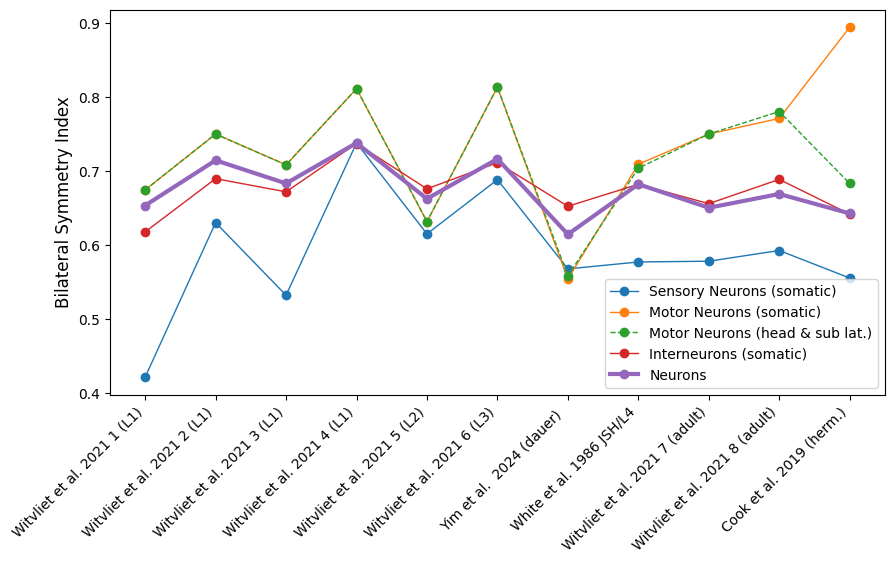

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_ylabel("Bilateral Symmetry Index", fontsize=12)

for view in symmetries:
    ax.plot([get_improved_reader_name(d) for d in datareaders], symmetries[view], \
            marker="o", linestyle="--" if "head" in view else "-", label=view, \
            linewidth=3 if view == "Neurons" else 1,)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.legend()
plt.show()